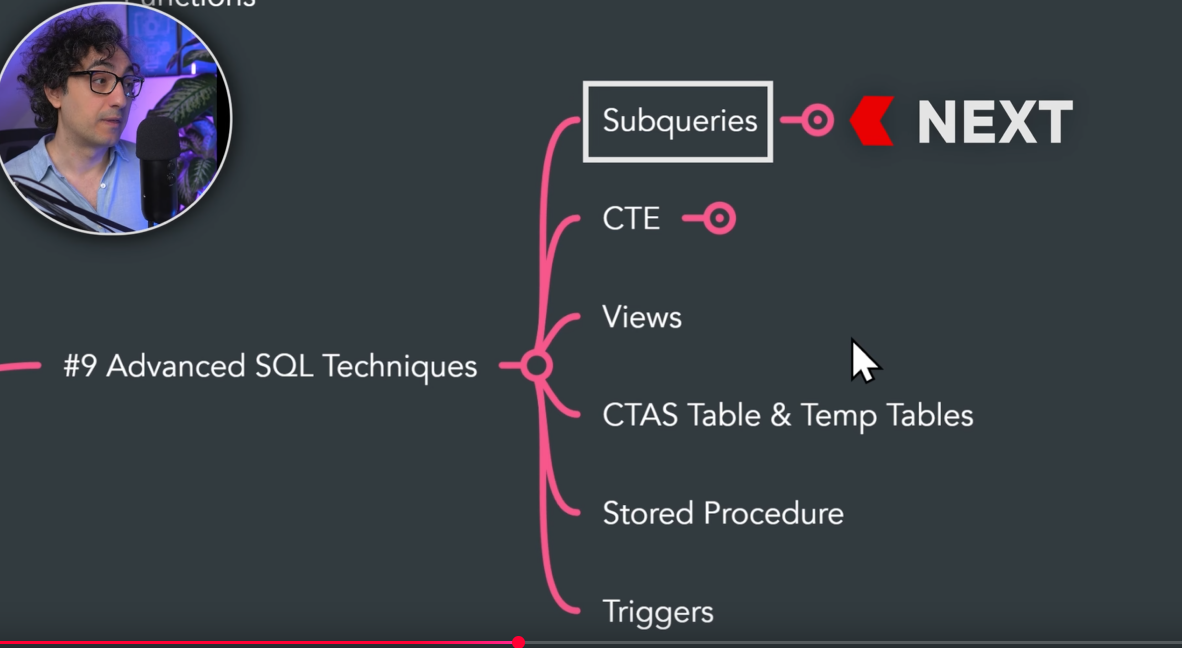

# Import required libraries

In [1]:
import pyodbc
import sys
sys.path.append("../..")
from utility.sql_utilities import SQLUtilities as ut

# Create Connection and Cursor for MyDatabase and SalesDB Databases

In [2]:
mydb_connector = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" "Server=BRIGHT-WORK\\SQLEXPRESS;" "Database=MyDatabase;" "Trusted_Connection=yes;")
mydb_cursor = mydb_connector.cursor()

salesdb_connector = pyodbc.connect("Driver={ODBC Driver 17 for SQL Server};" "Server=BRIGHT-WORK\\SQLEXPRESS;" "Database=SalesDB;" "Trusted_Connection=yes;")
salesdb_cursor = salesdb_connector.cursor()

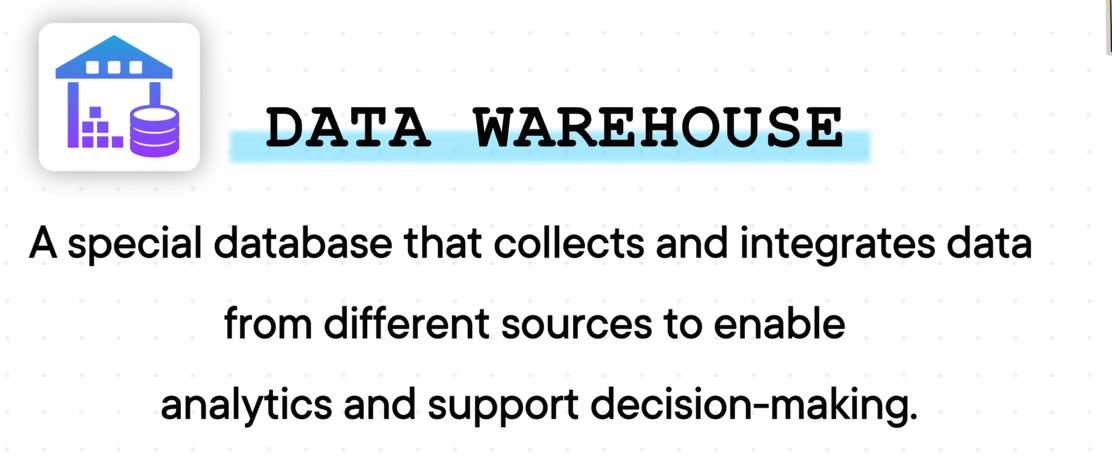

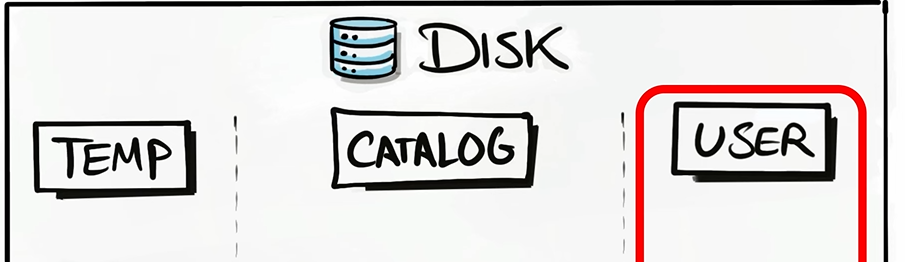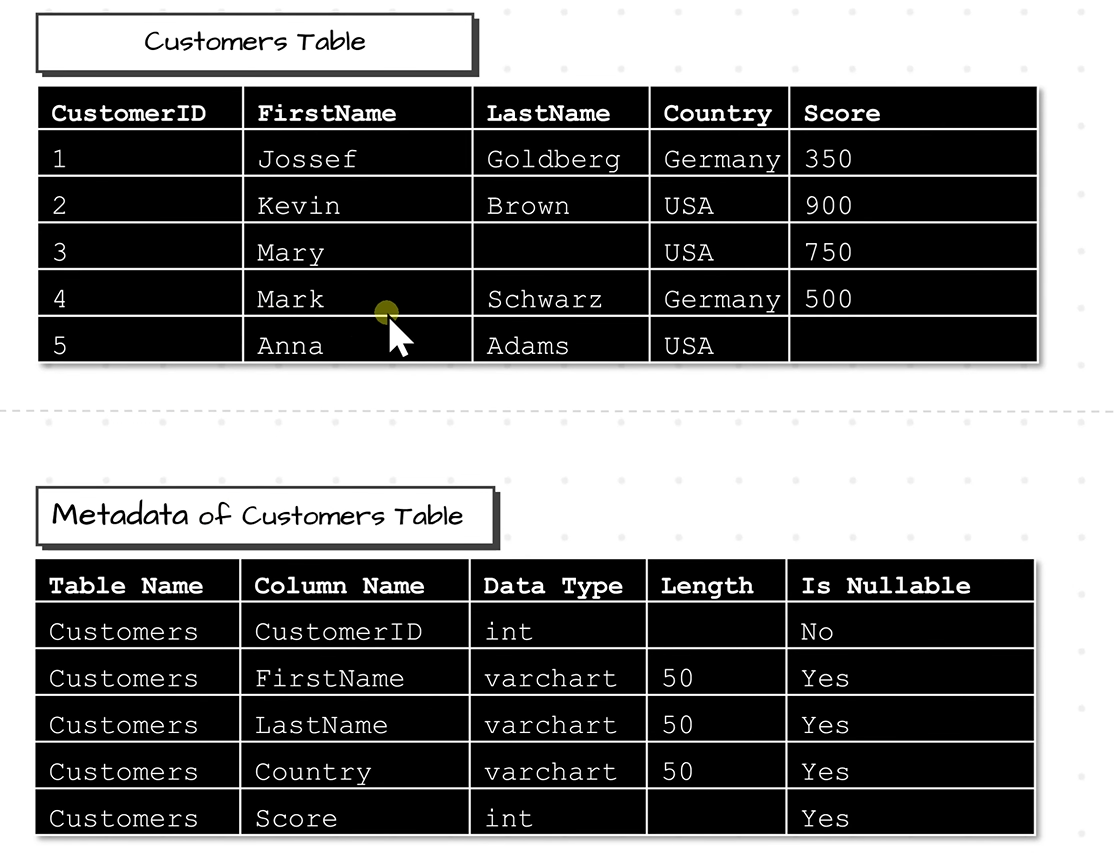
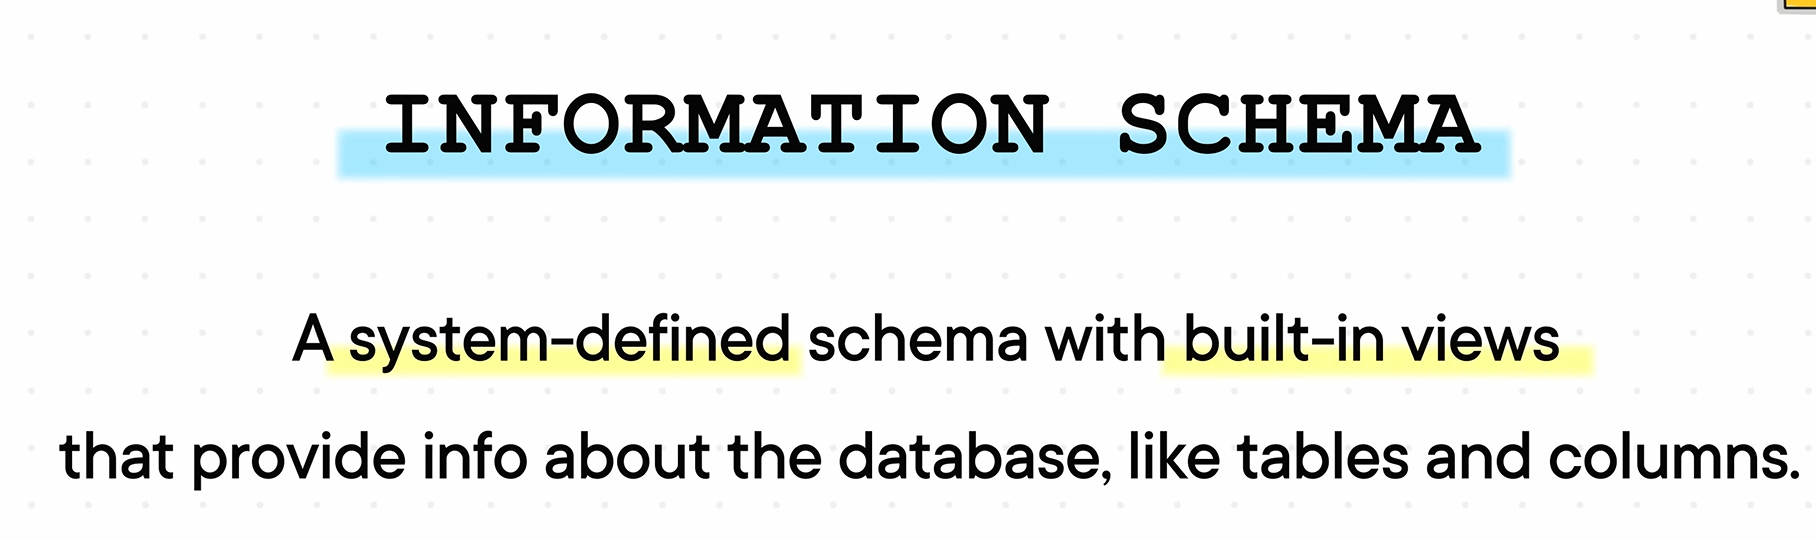

In [7]:
select_query: str = """
SELECT TABLE_CATALOG, TABLE_SCHEMA, TABLE_NAME, COLUMN_NAME, ORDINAL_POSITION, COLUMN_DEFAULT, IS_NULLABLE, DATA_TYPE
FROM INFORMATION_SCHEMA.COLUMNS;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------------+--------------+---------------+---------------+------------------+----------------+-------------+-----------+
| TABLE_CATALOG | TABLE_SCHEMA |  TABLE_NAME   |  COLUMN_NAME  | ORDINAL_POSITION | COLUMN_DEFAULT | IS_NULLABLE | DATA_TYPE |
+---------------+--------------+---------------+---------------+------------------+----------------+-------------+-----------+
|    SalesDB    |    Sales     |   Customers   |  CustomerID   |        1         |      NULL      |     NO      |    int    |
|    SalesDB    |    Sales     |   Customers   |   FirstName   |        2         |      NULL      |     YES     |  varchar  |
|    SalesDB    |    Sales     |   Customers   |   LastName    |        3         |      NULL      |     YES     |  varchar  |
|    SalesDB    |    Sales     |   Customers   |    Country    |        4         |      NULL      |     YES     |  varchar  |
|    SalesDB    |    Sales     |   Customers   |     Score     |        5         |      NULL      |     YES   

# Subqueries
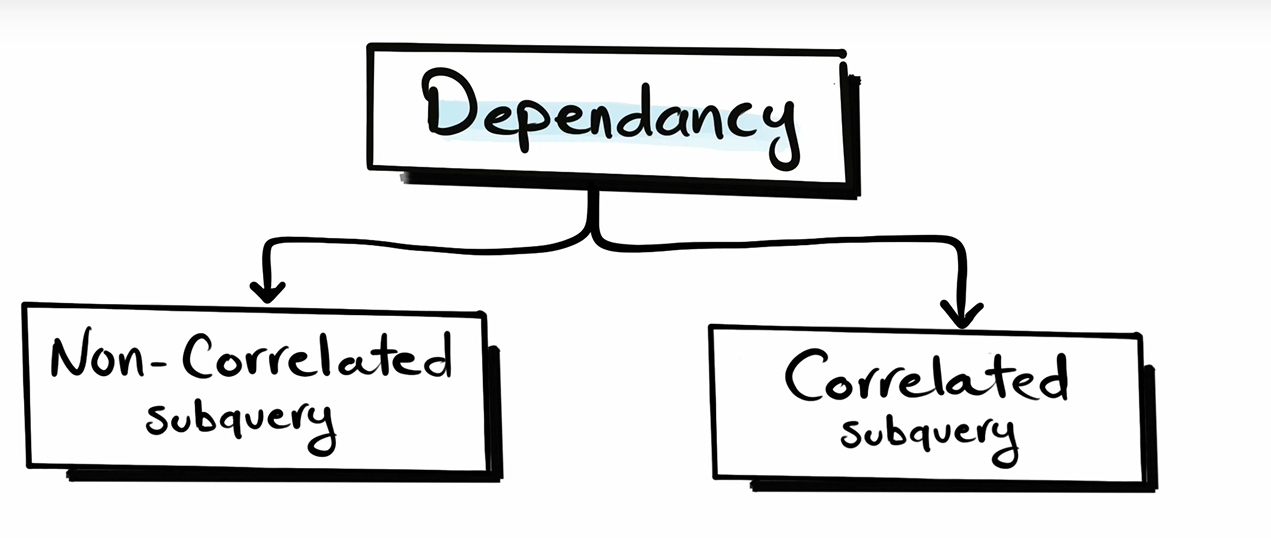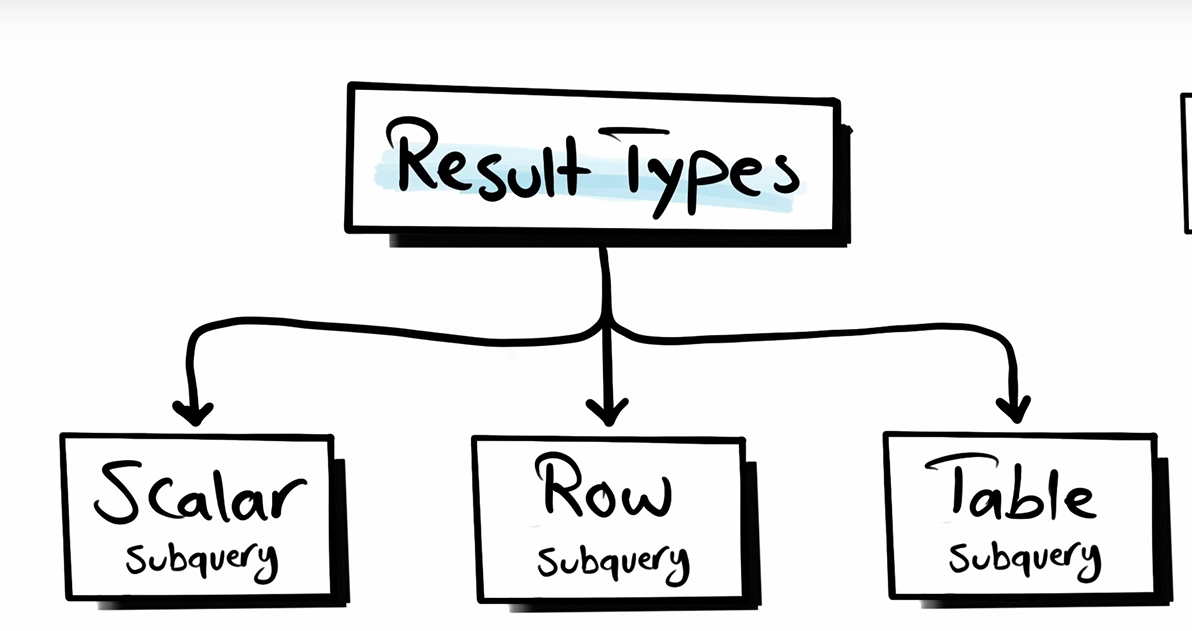
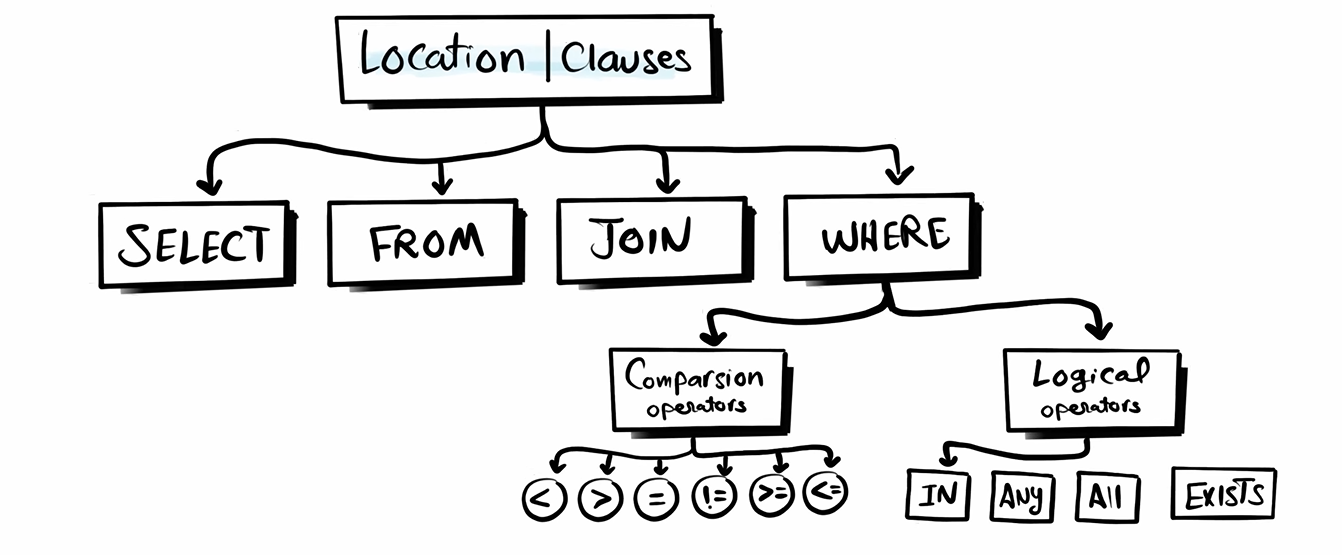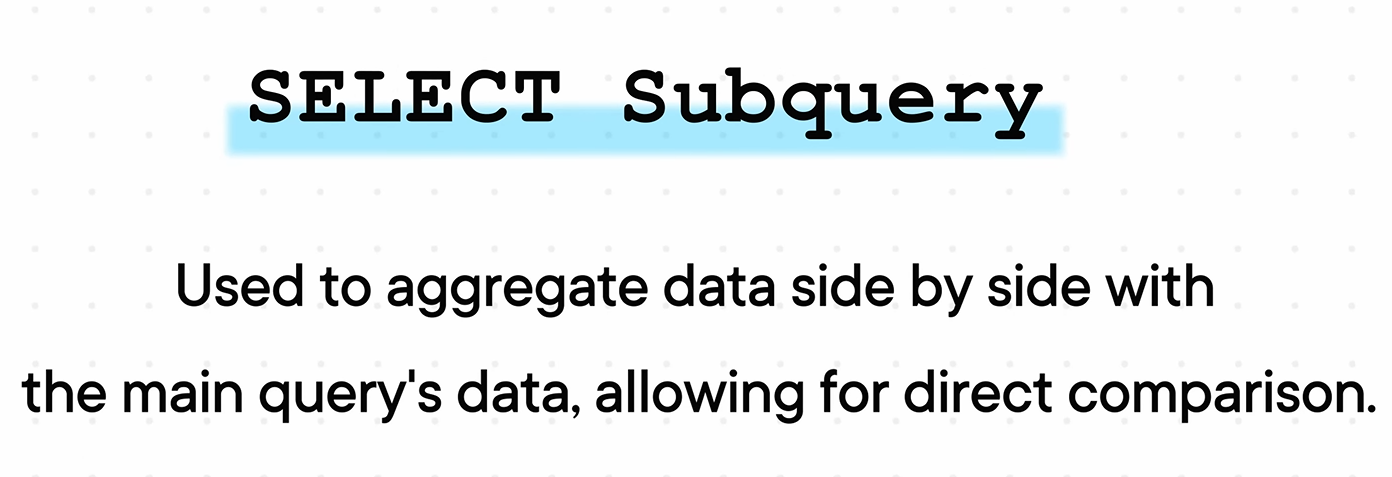
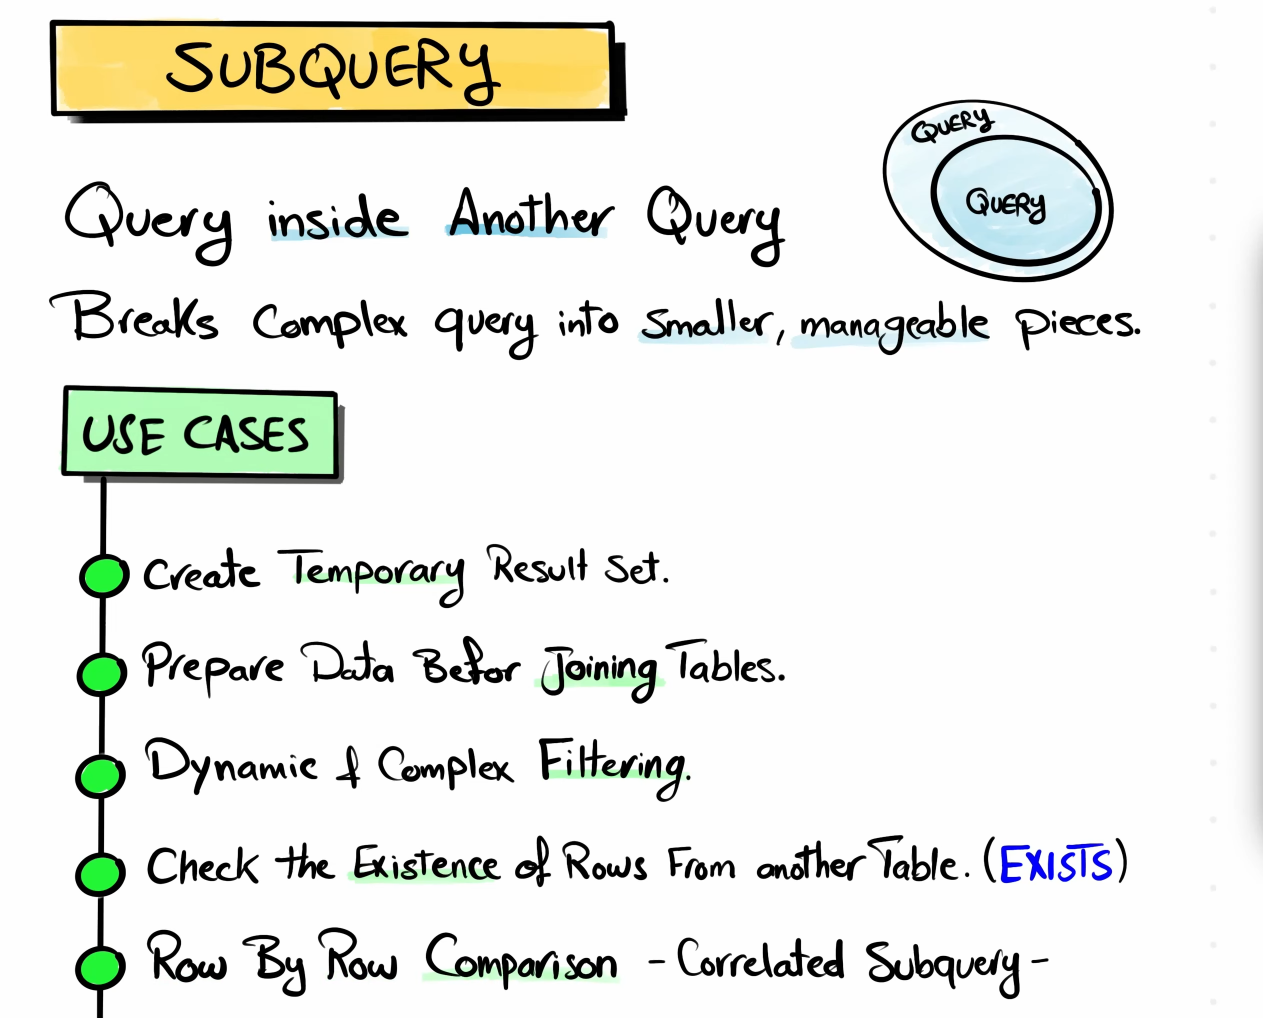

In [8]:
select_query: str = """
/* Scalar Query */
SELECT
    AVG(Sales) AS Avg_Sales
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* Row Query */
SELECT
    CustomerID
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* Table Query */
SELECT
    OrderID,
    OrderDate
FROM Sales.Orders;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-----------+
| Avg_Sales |
+-----------+
|    38     |
+-----------+
1 row returned in time: (0.02 sec)


+------------+
| CustomerID |
+------------+
|     2      |
|     3      |
|     1      |
|     1      |
|     2      |
|     3      |
|     1      |
|     4      |
|     2      |
|     3      |
+------------+
10 rows returned in time: (0.003 sec)


+---------+------------+
| OrderID | OrderDate  |
+---------+------------+
|    1    | 2025-01-01 |
|    2    | 2025-01-05 |
|    3    | 2025-01-10 |
|    4    | 2025-01-20 |
|    5    | 2025-02-01 |
|    6    | 2025-02-05 |
|    7    | 2025-02-15 |
|    8    | 2025-02-18 |
|    9    | 2025-03-10 |
|   10    | 2025-03-15 |
+---------+------------+
10 rows returned in time: (0.001 sec)




In [16]:
select_query: str = """
/* TASK 1:
   Find the products that have a price higher than the average price of all products.
*/

-- Main Query
SELECT
*
FROM (
    -- Subquery
    SELECT
        ProductID,
        Price,
        AVG(Price) OVER () AS AvgPrice
    FROM Sales.Products
) AS t
WHERE Price > AvgPrice;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)


select_query: str = """
SELECT
    ProductID,
    Price,
    AVG(Price) OVER () AS AvgPrice
FROM Sales.Products;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 1:
   Find the products that have a price higher than the average price of all products.
*/

SELECT
     ProductID,
     Price,
     (SELECT AVG(Price) FROM Sales.Products) AS AvgPrice
FROM Sales.Products
WHERE Price > (SELECT AVG(Price) FROM Sales.Products);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-----------+-------+----------+
| ProductID | Price | AvgPrice |
+-----------+-------+----------+
|    104    |  25   |    20    |
|    105    |  30   |    20    |
+-----------+-------+----------+
2 rows returned in time: (0.016 sec)


+-----------+-------+----------+
| ProductID | Price | AvgPrice |
+-----------+-------+----------+
|    101    |  10   |    20    |
|    102    |  15   |    20    |
|    103    |  20   |    20    |
|    104    |  25   |    20    |
|    105    |  30   |    20    |
+-----------+-------+----------+
5 rows returned in time: (0.001 sec)


+-----------+-------+----------+
| ProductID | Price | AvgPrice |
+-----------+-------+----------+
|    104    |  25   |    20    |
|    105    |  30   |    20    |
+-----------+-------+----------+
2 rows returned in time: (0.004 sec)




In [18]:
select_query: str = """
/* TASK 2:
   Rank Customers based on their total amount of sales.
*/
-- Main Query
SELECT
    *,
    RANK() OVER (ORDER BY TotalSales DESC) AS CustomerRank
FROM (
    -- Subquery
    SELECT
        CustomerID,
        SUM(Sales) AS TotalSales
    FROM Sales.Orders
    GROUP BY CustomerID
) AS t;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
SELECT
    CustomerID,
    SUM(Sales) AS TotalSales
FROM Sales.Orders
GROUP BY CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+------------+--------------+
| CustomerID | TotalSales | CustomerRank |
+------------+------------+--------------+
|     3      |    125     |      1       |
|     1      |    110     |      2       |
|     4      |     90     |      3       |
|     2      |     55     |      4       |
+------------+------------+--------------+
4 rows returned in time: (0.023 sec)


+------------+------------+
| CustomerID | TotalSales |
+------------+------------+
|     1      |    110     |
|     2      |     55     |
|     3      |    125     |
|     4      |     90     |
+------------+------------+
4 rows returned in time: (0.006 sec)




In [19]:
select_query: str = """
/* TASK 3:
   Show the product IDs, product names, prices, and the total number of orders.
*/
-- Main Query
SELECT
    ProductID,
    Product,
    Price,
    (SELECT COUNT(*) FROM Sales.Orders) AS TotalOrders -- Subquery
FROM Sales.Products;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-----------+---------+-------+-------------+
| ProductID | Product | Price | TotalOrders |
+-----------+---------+-------+-------------+
|    101    | Bottle  |  10   |     10      |
|    102    |  Tire   |  15   |     10      |
|    103    |  Socks  |  20   |     10      |
|    104    |  Caps   |  25   |     10      |
|    105    | Gloves  |  30   |     10      |
+-----------+---------+-------+-------------+
5 rows returned in time: (0.026 sec)




In [22]:
select_query: str = """
/* TASK 4:
   Show customer details along with their total sales.
*/
-- Main Query
SELECT
    c.*,
    t.TotalSales
FROM Sales.Customers AS c
LEFT JOIN ( 
    -- Subquery
    SELECT
        CustomerID,
        SUM(Sales) AS TotalSales
    FROM Sales.Orders
    GROUP BY CustomerID
) AS t
ON c.CustomerID = t.CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
SELECT
    CustomerID,
    SUM(Sales) AS TotalSales
FROM Sales.Orders
GROUP BY CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+---------+-------+------------+
| CustomerID | FirstName | LastName | Country | Score | TotalSales |
+------------+-----------+----------+---------+-------+------------+
|     1      |  Jossef   | Goldberg | Germany |  350  |    110     |
|     2      |   Kevin   |  Brown   |   USA   |  900  |     55     |
|     3      |   Mary    |   NULL   |   USA   |  750  |    125     |
|     4      |   Mark    | Schwarz  | Germany |  500  |     90     |
|     5      |   Anna    |  Adams   |   USA   | NULL  |    NULL    |
+------------+-----------+----------+---------+-------+------------+
5 rows returned in time: (0.023 sec)


+------------+------------+
| CustomerID | TotalSales |
+------------+------------+
|     1      |    110     |
|     2      |     55     |
|     3      |    125     |
|     4      |     90     |
+------------+------------+
4 rows returned in time: (0.002 sec)




In [24]:
select_query: str = """
/* TASK 5:
   Show all customer details and the total orders of each customer.
*/
-- Main Query
SELECT
    c.*,
    o.TotalOrders
FROM Sales.Customers AS c
LEFT JOIN (
    -- Subquery
    SELECT
        CustomerID,
        COUNT(*) AS TotalOrders
    FROM Sales.Orders
    GROUP BY CustomerID
) AS o
ON c.CustomerID = o.CustomerID;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+---------+-------+-------------+
| CustomerID | FirstName | LastName | Country | Score | TotalOrders |
+------------+-----------+----------+---------+-------+-------------+
|     1      |  Jossef   | Goldberg | Germany |  350  |      3      |
|     2      |   Kevin   |  Brown   |   USA   |  900  |      3      |
|     3      |   Mary    |   NULL   |   USA   |  750  |      3      |
|     4      |   Mark    | Schwarz  | Germany |  500  |      1      |
|     5      |   Anna    |  Adams   |   USA   | NULL  |    NULL     |
+------------+-----------+----------+---------+-------+-------------+
5 rows returned in time: (0.01 sec)




In [25]:
select_query: str = """
/* TASK 6:
   Find the products that have a price higher than the average price of all products.
*/
-- Main Query
SELECT
    ProductID,
    Price,
    (SELECT AVG(Price) FROM Sales.Products) AS AvgPrice -- Subquery
FROM Sales.Products
WHERE Price > (SELECT AVG(Price) FROM Sales.Products); -- Subquery
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+-----------+-------+----------+
| ProductID | Price | AvgPrice |
+-----------+-------+----------+
|    104    |  25   |    20    |
|    105    |  30   |    20    |
+-----------+-------+----------+
2 rows returned in time: (0.018 sec)




In [29]:
select_query: str = """
/* TASK 7:
   Show the details of orders made by customers in Germany.
*/
-- Main Query
SELECT
    *
FROM Sales.Orders
WHERE CustomerID IN (
    -- Subquery
    SELECT
        CustomerID
    FROM Sales.Customers
    WHERE Country = 'Germany'
);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
SELECT
    *
FROM Sales.Customers
WHERE Country = 'Germany'
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)



select_query: str = """
/* TASK 8:
   Show the details of orders made by customers not in Germany.
*/
-- Main Query
SELECT
    *
FROM Sales.Orders
WHERE CustomerID NOT IN (
    -- Subquery
    SELECT
        CustomerID
    FROM Sales.Customers
    WHERE Country = 'Germany'
);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+-----------+------------+---------------+------------+------------+-------------+-------------------+--------------+----------+-------+---------------------+
| OrderID | ProductID | CustomerID | SalesPersonID | OrderDate  |  ShipDate  | OrderStatus |    ShipAddress    | BillAddress  | Quantity | Sales |    CreationTime     |
+---------+-----------+------------+---------------+------------+------------+-------------+-------------------+--------------+----------+-------+---------------------+
|    3    |    101    |     1      |       5       | 2025-01-10 | 2025-01-25 |  Delivered  |   8157 W. Book    | 8157 W. Book |    2     |  20   | 2025-01-10 18:24:08 |
|    4    |    105    |     1      |       3       | 2025-01-20 | 2025-01-25 |   Shipped   | 5724 Victory Lane |              |    2     |  60   | 2025-01-20 05:50:33 |
|    7    |    102    |     1      |       1       | 2025-02-15 | 2025-02-27 |  Delivered  | 136 Balboa Court  |              |    2     |  30   | 2025-02-

In [32]:
select_query: str = """
/* TASK 9:
Find female employees whose salaries are greater than the salaries of any male employees.
*/
SELECT
    EmployeeID, 
    FirstName,
    Salary
FROM Sales.Employees
WHERE Gender = 'F'
AND Salary > ANY (
  SELECT Salary
  FROM Sales.Employees
WHERE Gender = 'M'
);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
SELECT *
FROM Sales.Employees
WHERE Gender = 'M'
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+--------+
| EmployeeID | FirstName | Salary |
+------------+-----------+--------+
|     3      |   Mary    | 75000  |
+------------+-----------+--------+
1 row returned in time: (0.041 sec)


+------------+-----------+----------+------------+------------+--------+--------+-----------+
| EmployeeID | FirstName | LastName | Department | BirthDate  | Gender | Salary | ManagerID |
+------------+-----------+----------+------------+------------+--------+--------+-----------+
|     1      |   Frank   |   Lee    | Marketing  | 1988-12-05 |   M    | 55000  |   NULL    |
|     2      |   Kevin   |  Brown   | Marketing  | 1972-11-25 |   M    | 65000  |     1     |
|     4      |  Michael  |   Ray    |   Sales    | 1977-02-10 |   M    | 90000  |     2     |
+------------+-----------+----------+------------+------------+--------+--------+-----------+
3 rows returned in time: (0.007 sec)




In [33]:
select_query: str = """
/* TASK 10:
   Show all customer details and the total orders for each customer using a correlated subquery.
*/
SELECT
    *,
    (SELECT COUNT(*)
     FROM Sales.Orders o
     WHERE o.CustomerID = c.CustomerID) AS TotalSales
FROM Sales.Customers AS c;
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+------------+-----------+----------+---------+-------+------------+
| CustomerID | FirstName | LastName | Country | Score | TotalSales |
+------------+-----------+----------+---------+-------+------------+
|     1      |  Jossef   | Goldberg | Germany |  350  |     3      |
|     2      |   Kevin   |  Brown   |   USA   |  900  |     3      |
|     3      |   Mary    |   NULL   |   USA   |  750  |     3      |
|     4      |   Mark    | Schwarz  | Germany |  500  |     1      |
|     5      |   Anna    |  Adams   |   USA   | NULL  |     0      |
+------------+-----------+----------+---------+-------+------------+
5 rows returned in time: (0.022 sec)




In [39]:
select_query: str = """
/* TASK 11:
   Show the details of orders made by customers in Germany.
*/
SELECT
    *
FROM Sales.Orders AS o
WHERE EXISTS (
    SELECT 1
    FROM Sales.Customers AS c
    WHERE Country = 'Germany'
AND o.CustomerID = c.CustomerID
);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
SELECT *
FROM Sales.Customers
WHERE Country = 'Germany'
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

select_query: str = """
/* TASK 12:
   Show the details of orders made by customers not in Germany.
*/
SELECT
    *
FROM Sales.Orders AS o
WHERE NOT EXISTS (
    SELECT 1
    FROM Sales.Customers AS c
    WHERE Country = 'Germany'
AND o.CustomerID = c.CustomerID
);
"""
ut.execute_display_query_results(query=select_query, cursor_object=salesdb_cursor)

+---------+-----------+------------+---------------+------------+------------+-------------+-------------------+--------------+----------+-------+---------------------+
| OrderID | ProductID | CustomerID | SalesPersonID | OrderDate  |  ShipDate  | OrderStatus |    ShipAddress    | BillAddress  | Quantity | Sales |    CreationTime     |
+---------+-----------+------------+---------------+------------+------------+-------------+-------------------+--------------+----------+-------+---------------------+
|    3    |    101    |     1      |       5       | 2025-01-10 | 2025-01-25 |  Delivered  |   8157 W. Book    | 8157 W. Book |    2     |  20   | 2025-01-10 18:24:08 |
|    4    |    105    |     1      |       3       | 2025-01-20 | 2025-01-25 |   Shipped   | 5724 Victory Lane |              |    2     |  60   | 2025-01-20 05:50:33 |
|    7    |    102    |     1      |       1       | 2025-02-15 | 2025-02-27 |  Delivered  | 136 Balboa Court  |              |    2     |  30   | 2025-02-

# Common Table Expressions (CTE)
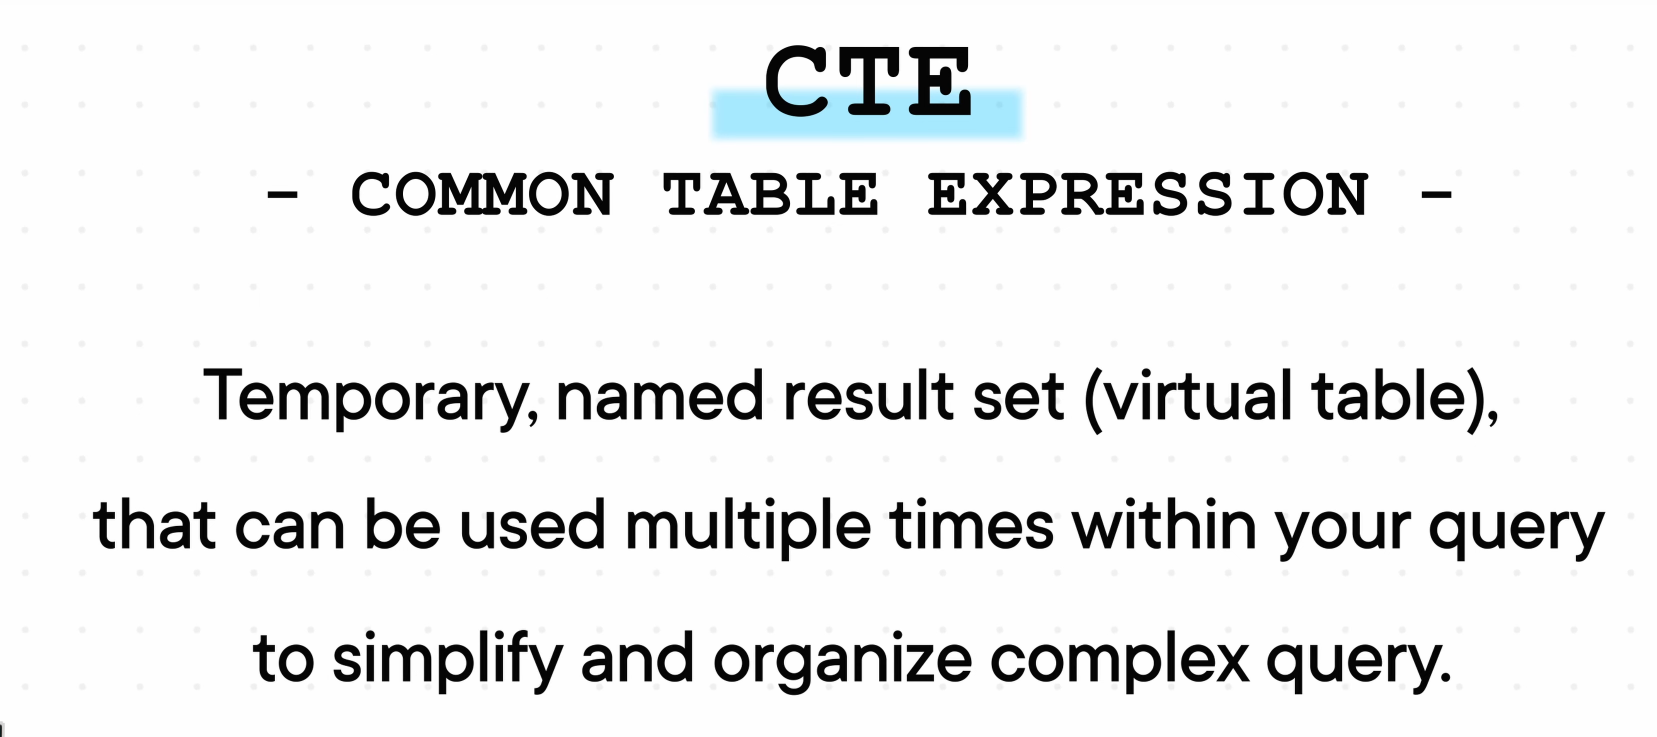